In [1]:
import tensorflow as tf
from tensorflow import keras
from keras import layers

import matplotlib.pyplot as plt
import matplotlib.image as img
import PIL.Image as Image
import cv2

import os
import numpy as np
import pathlib

from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import ModelCheckpoint

2026-05-11 12:57:21.706155: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778504242.216851      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778504242.346283      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778504243.441718      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778504243.441792      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778504243.441799      57 computation_placer.cc:177] computation placer alr

In [31]:
# CONSTANTS

data_dir_path = '/kaggle/input/datasets/muratkokludataset/rice-image-dataset/Rice_Image_Dataset'
IMG_HEIGHT = 224
IMG_WIDTH = 224
INPUT_SHAPE = (224, 224, 3)
LAYERS_TO_FREEZE = 140
NUM_CLASSES = 5
LEARNING_RATE = 0.00007
EPOCHS = 30
BATCH_SIZE = 8
SAVE_BEST_MODEL_ADDRESS = 'weights.best.image_netv2.rice.keras'

In [3]:
data_dir = pathlib.Path(data_dir_path)
data_dir

PosixPath('/kaggle/input/datasets/muratkokludataset/rice-image-dataset/Rice_Image_Dataset')

In [4]:
arborio = list(data_dir.glob('Arborio/*'))[:600]
basmati = list(data_dir.glob('Basmati/*'))[:600]
ipsala = list(data_dir.glob('Ipsala/*'))[:600]
jasmine = list(data_dir.glob('Jasmine/*'))[:600]
karacadag = list(data_dir.glob('Karacadag/*'))[:600]

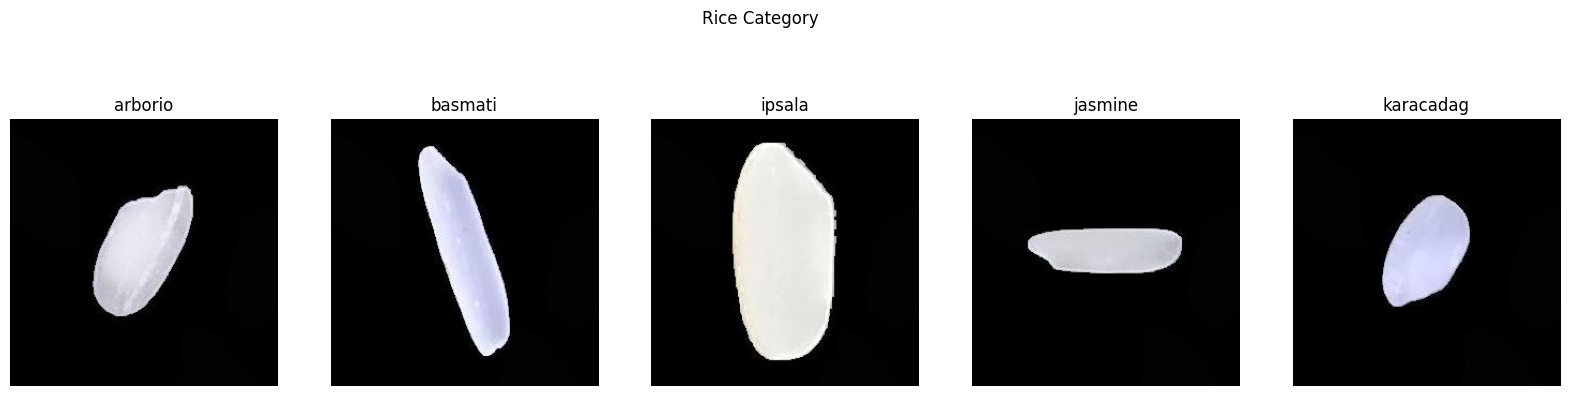

In [5]:
fig, axes = plt.subplots(ncols=5, figsize=(20,5))
fig.suptitle('Rice Category')
images = [img.imread(arborio[0]),
    img.imread(basmati[0]),
    img.imread(ipsala[0]),
    img.imread(jasmine[0]),
    img.imread(karacadag[0])]

class_names = ['arborio', 'basmati', 'ipsala', 'jasmine', 'karacadag']
for i in range(len(axes)):
    axes[i].set_title(class_names[i])
    axes[i].imshow(images[i])
    axes[i].axis('off')

In [6]:
df_images = {
    'arborio': arborio,
    'basmati': basmati,
    'ipsala': ipsala,
    'jasmine': jasmine,
    'karacadag': karacadag,
}

df_labels = {}
df_i_labels = {}
for i, label in enumerate(list(df_images.keys())):
    df_labels[label] = i
    df_i_labels[i] = label


In [7]:
img = cv2.imread(df_images['arborio'][0])
img.shape

(250, 250, 3)

In [8]:
X, y = [], []
for label, images in df_images.items():
    for image in images:
        img = cv2.imread(image)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        resized_img = cv2.resize(img, (IMG_HEIGHT, IMG_WIDTH))
        X.append(resized_img)
        y.append(df_labels[label])

In [9]:
X = np.array(X)
y = np.array(y)

In [10]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

print(f'X_train number of samples: {len(X_train)}')
print(f'X_val number of samples: {len(X_val)}')
print(f'X_test number of samples: {len(X_test)}')

X_train number of samples: 2100
X_val number of samples: 450
X_test number of samples: 450


In [32]:
training_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train))
validation_dataset = tf.data.Dataset.from_tensor_slices((X_val, y_val))
testing_dataset = tf.data.Dataset.from_tensor_slices((X_test, y_test))

AUTOTUNE = tf.data.AUTOTUNE
training_dataset = training_dataset.prefetch(AUTOTUNE).shuffle(training_dataset.cardinality()).batch(BATCH_SIZE)
validation_dataset = validation_dataset.prefetch(AUTOTUNE).shuffle(validation_dataset.cardinality()).batch(BATCH_SIZE)
testing_dataset = testing_dataset.prefetch(AUTOTUNE).shuffle(testing_dataset.cardinality()).batch(BATCH_SIZE)

In [33]:
base_model = keras.applications.MobileNetV2(
    input_shape = INPUT_SHAPE,
    include_top = False,
    weights='imagenet'
)

for layer in base_model.layers[:LAYERS_TO_FREEZE]:
    layer.trainable = False

In [34]:
inputs = keras.Input(shape=INPUT_SHAPE)
x = keras.applications.mobilenet_v2.preprocess_input(inputs)
x = base_model(x)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(512, activation='relu')(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(256, activation='relu')(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

model = keras.Model(inputs, outputs)

In [35]:
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_2 (TrueDivide)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_2 (Subtract)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,046,469 (11.62 MB)

 Trainable params: 1,828,485 (6.98 MB)

 Non-trainable params: 1,217,984 (4.65 MB)

In [36]:
checkpointer = ModelCheckpoint(filepath=SAVE_BEST_MODEL_ADDRESS, verbose=1, save_best_only=True)

In [37]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy'],

)

In [38]:
history = model.fit(
    training_dataset,
    steps_per_epoch = len(X_train) // BATCH_SIZE,
    epochs=EPOCHS,
    validation_data = validation_dataset,
    validation_steps = len(X_val) // BATCH_SIZE,
    callbacks=[checkpointer]
)

Epoch 1/30


2026-05-11 13:04:40.625313: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-11 13:04:40.762560: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


261/262 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7219 - loss: 0.7858
Epoch 1: val_loss improved from inf to 0.23625, saving model to weights.best.image_netv2.rice.keras
262/262 ━━━━━━━━━━━━━━━━━━━━ 29s 35ms/step - accuracy: 0.7229 - loss: 0.7832 - val_accuracy: 0.9174 - val_loss: 0.2363
Epoch 2/30


2026-05-11 13:05:03.132109: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-11 13:05:03.268728: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-11 13:05:03.404963: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


  1/262 ━━━━━━━━━━━━━━━━━━━━ 57:54 13s/step - accuracy: 0.7500 - loss: 0.3042
Epoch 2: val_loss did not improve from 0.23625
262/262 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step - accuracy: 0.7500 - loss: 0.3042 - val_accuracy: 0.9196 - val_loss: 0.2370
Epoch 3/30
261/262 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9338 - loss: 0.1917
Epoch 3: val_loss improved from 0.23625 to 0.21860, saving model to weights.best.image_netv2.rice.keras
262/262 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.9339 - loss: 0.1916 - val_accuracy: 0.9174 - val_loss: 0.2186
Epoch 4/30
  1/262 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.5000 - loss: 2.2366
Epoch 4: val_loss did not improve from 0.21860
262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5000 - loss: 2.2366 - val_accuracy: 0.8906 - val_loss: 0.2585
Epoch 5/30
261/262 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9570 - loss: 0.1399
Epoch 5: val_loss did not improve from 0.21860
262/262 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.9570 - l

In [39]:
model.load_weights(SAVE_BEST_MODEL_ADDRESS)

In [40]:
model.evaluate(testing_dataset)

57/57 ━━━━━━━━━━━━━━━━━━━━ 4s 67ms/step - accuracy: 0.9911 - loss: 0.0271


[0.03134453296661377, 0.9888888597488403]

In [41]:
y_pred = model.predict(X_test, batch_size=64, verbose=1)
y_pred_bool = np.argmax(y_pred, axis=-1)

print(classification_report(y_test, y_pred_bool))

8/8 ━━━━━━━━━━━━━━━━━━━━ 9s 671ms/step
              precision    recall  f1-score   support

           0       1.00      0.97      0.98        90
           1       0.99      0.99      0.99        90
           2       1.00      1.00      1.00        90
           3       0.99      0.99      0.99        90
           4       0.97      1.00      0.98        90

    accuracy                           0.99       450
   macro avg       0.99      0.99      0.99       450
weighted avg       0.99      0.99      0.99       450



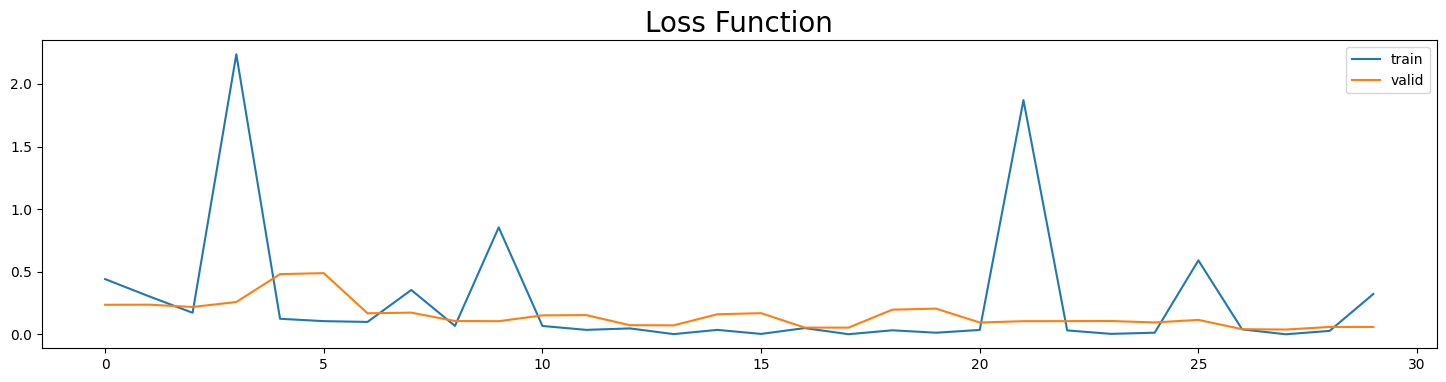

In [42]:
plt.figure(figsize=(18,4))
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='valid')
plt.legend()
plt.title('Loss Function', fontsize=20)
plt.show()

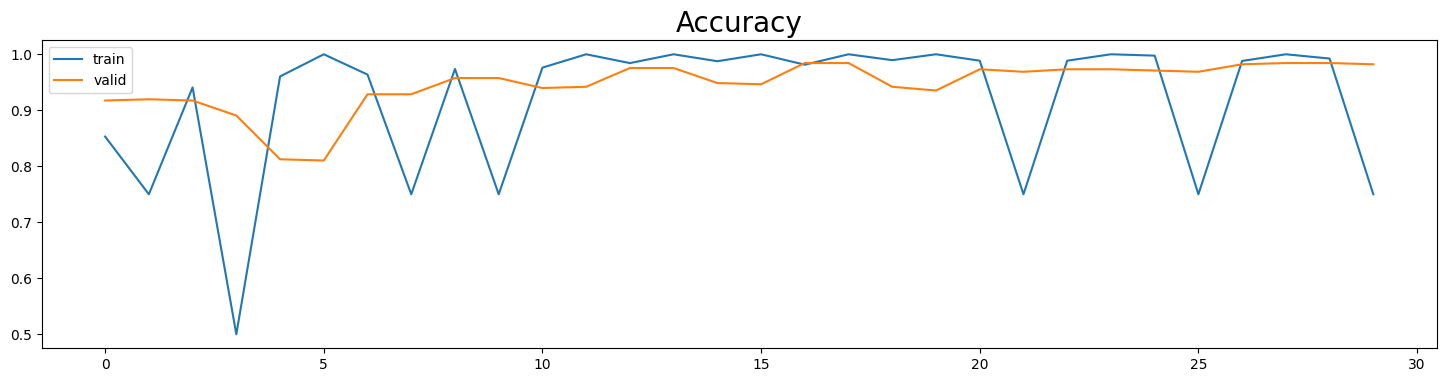

In [43]:
plt.figure(figsize=(18,4))
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='valid')
plt.legend()
plt.title('Accuracy', fontsize=20)
plt.show()

In [44]:
right_idx = []
wrong_idx = []

for i, (pred, actual) in enumerate(zip(y_pred_bool, y_test)):
    if pred == actual:
        right_idx.append(i)
    else:
        wrong_idx.append(i)

right_idx = np.array(right_idx)
wrong_idx = np.array(wrong_idx)

np.random.shuffle(right_idx)
np.random.shuffle(wrong_idx)

print(f'{len(wrong_idx)} samples were wrong')
print(f'{len(right_idx)} samples were right')

5 samples were wrong
445 samples were right


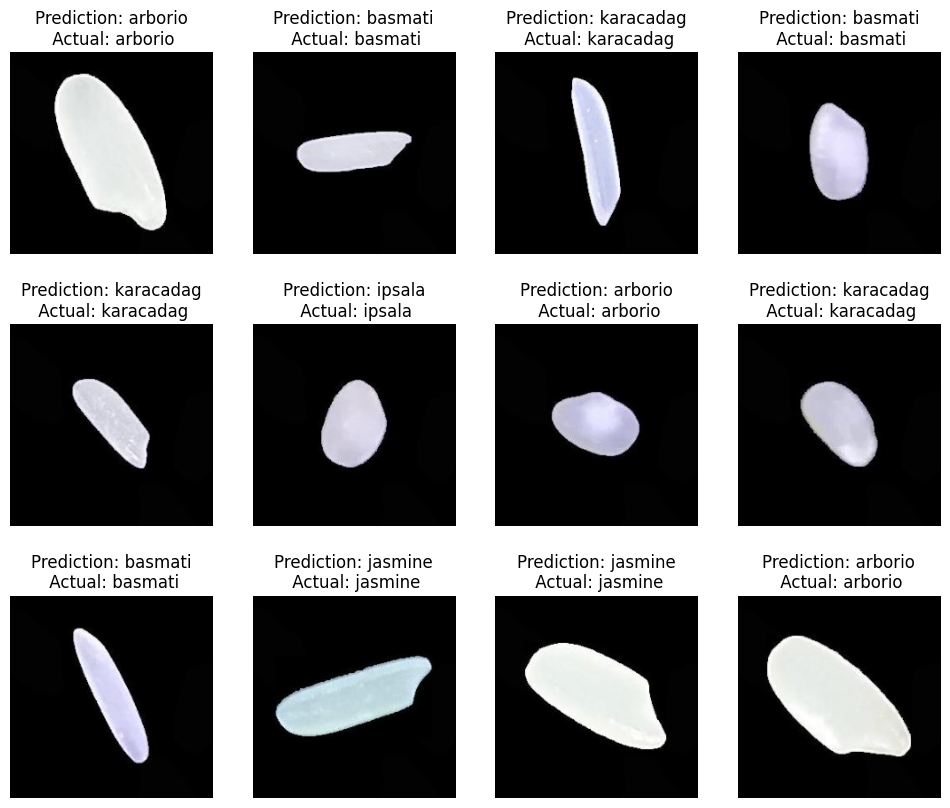

In [45]:
# Presenting some that were predicted correctly
NUM_SAMPLES_TO_SHOW = 12

fig, axes = plt.subplots(3, 4, figsize=(12, 10))
axes = axes.flatten()

for i in range(NUM_SAMPLES_TO_SHOW):
    axes[i].imshow(X_test[i])
    axes[i].set_title(f'Prediction: {df_i_labels[y_pred_bool[right_idx[i]]]}\n Actual: {df_i_labels[y_test[right_idx[i]]]}')
    axes[i].axis('off')

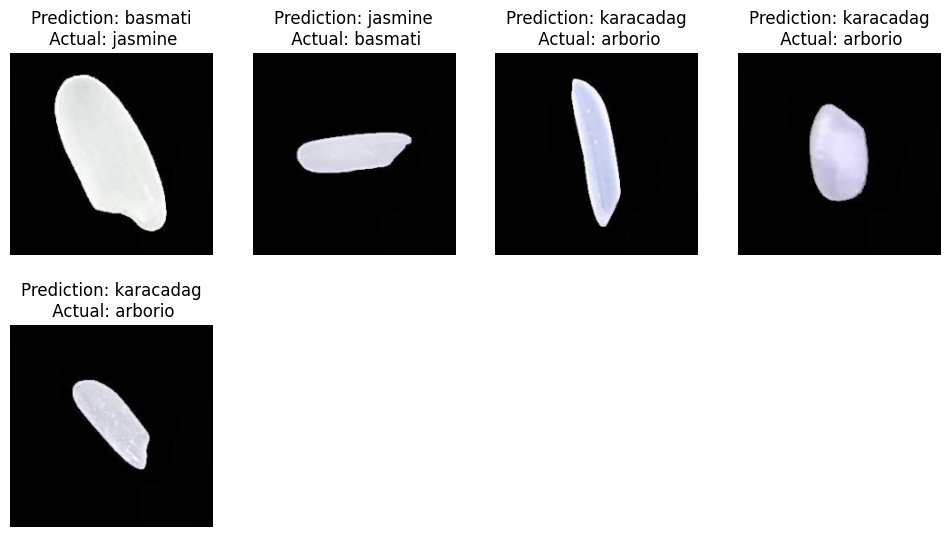

In [46]:
# Presenting some that were predicted wrongly

fig, axes = plt.subplots(3, 4, figsize=(12, 10))
axes = axes.flatten()

for i in range(min(NUM_SAMPLES_TO_SHOW, len(wrong_idx))):
    axes[i].imshow(X_test[i])
    axes[i].set_title(f'Prediction: {df_i_labels[y_pred_bool[wrong_idx[i]]]}\n Actual: {df_i_labels[y_test[wrong_idx[i]]]}')
    axes[i].axis('off')

for i in range(min(len(wrong_idx), NUM_SAMPLES_TO_SHOW), NUM_SAMPLES_TO_SHOW):
    plt.delaxes(axes[i])